In [50]:
import numpy as np
import torch
from huggingface_hub import notebook_login
from datasets import load_dataset, load_metric 
from transformers import (AutoFeatureExtractor, 
    AutoModelForImageClassification, 
    TrainingArguments, 
    Trainer,
    pipeline)
from torchvision.transforms import (
    CenterCrop,
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomResizedCrop,
    Resize,
    ToTensor,
)
from PIL import Image
import requests
import matplotlib.pyplot as plt
from pynvml import *

In [22]:
model_checkpoint = "google/vit-base-patch16-224"
batch_size = 32

In [4]:
notebook_login()

Login successful
Your token has been saved to /home/jeevan/.huggingface/token
Authenticated through git-credential store but this isn't the helper defined on your machine.
You might have to re-authenticate when pushing to the Hugging Face Hub. Run the following command in your terminal in case you want to set this credential helper as the default

git config --global credential.helper store


### Load Dataset

In [7]:
dataset = load_dataset("imagefolder", data_dir="NWPU-RESISC45_original")

Resolving data files:   0%|          | 0/31500 [00:00<?, ?it/s]

Using custom data configuration default-c97aeb8aa5f5773e


Extracting data files: 0it [00:00, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset imagefolder downloaded and prepared to /home/jeevan/.cache/huggingface/datasets/imagefolder/default-c97aeb8aa5f5773e/0.0.0/48efdc62d40223daee675ca093d163bcb6cb0b7d7f93eb25aebf5edca72dc597. Subsequent calls will reuse this data.


  0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
acc = load_metric("accuracy")

In [10]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 31500
    })
})

Access an example from the dataset:
1. Select a split
2. Give an index
3. View image (and resize) and check labels

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256 at 0x7F3D787BBEE0>, 'label': 21}
21


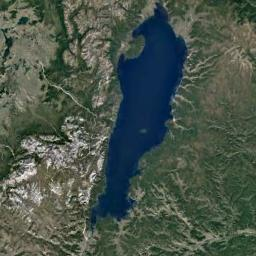

In [15]:
example = dataset["train"][15000]
print(example)
print(example['label'])
example['image']

Huggingface encoded the labels into integers for convenience.
Create dictionary to obtain string label from integer id.

In [16]:
labels = dataset["train"].features["label"].names
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = i
    id2label[i] = label

id2label[21]

'lake'

### Preprocess Data

Resize images + normalize the RGB colour channels using mean and st dev - image transformations.
We will not conduct data augmentations at the moment.

AutoFeatureExtractor.from_pretrained allows us to obtain the correct sizes, means, and st devs for the model architecture.

In [23]:
feature_extractor = AutoFeatureExtractor.from_pretrained(model_checkpoint)
feature_extractor

Downloading:   0%|          | 0.00/160 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/68.0k [00:00<?, ?B/s]

ViTFeatureExtractor {
  "do_normalize": true,
  "do_resize": true,
  "feature_extractor_type": "ViTFeatureExtractor",
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "size": 224
}

In [24]:
example['image'].size

(256, 256)

In [25]:
normalize = Normalize(mean = feature_extractor.image_mean, std = feature_extractor.image_std)

transforms = Compose(
        [
            Resize(feature_extractor.size),
            ToTensor(),
            normalize
        ])

def preprocess(batch):
    """Apply transforms across a batch."""
    batch["pixel_values"] = [
        transforms(image.convert("RGB")) for image in batch["image"] 
    ]
    return batch

If we conducted data augmentations (e.g. random flips, random crops), we would have two preprocessing functions - one for train, one for validation. We would not apply augmentations to the validation set.

In [26]:
dataset["train"].set_transform(preprocess)

#Split the training set into train + validation
splits = dataset["train"].train_test_split(test_size = 0.1)
train_ds = splits["train"]
val_ds = splits["test"]
#If conducting augmentations, the set_transform would go after splitting the dataset - one for train, one for val

We have added a 'pixel_values' feature to each data element, as can be seen below.

In [27]:
train_ds[0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=256x256>,
 'label': 1,
 'pixel_values': tensor([[[ 0.6314,  0.6235,  0.6314,  ...,  0.2235,  0.2314,  0.2235],
          [ 0.6549,  0.6549,  0.6706,  ...,  0.2314,  0.2549,  0.2471],
          [ 0.6706,  0.6706,  0.6706,  ...,  0.2392,  0.2627,  0.2627],
          ...,
          [ 0.5843,  0.5686,  0.5686,  ...,  0.6157,  0.6392,  0.6549],
          [ 0.6157,  0.6157,  0.6157,  ...,  0.5765,  0.6235,  0.6627],
          [ 0.6392,  0.6392,  0.6392,  ...,  0.5529,  0.6078,  0.6784]],
 
         [[ 0.4980,  0.4902,  0.4980,  ...,  0.2314,  0.2235,  0.2078],
          [ 0.5216,  0.5216,  0.5373,  ...,  0.2392,  0.2471,  0.2314],
          [ 0.5373,  0.5373,  0.5373,  ...,  0.2471,  0.2549,  0.2471],
          ...,
          [ 0.4431,  0.4353,  0.4431,  ...,  0.4980,  0.5216,  0.5373],
          [ 0.4745,  0.4745,  0.4902,  ...,  0.4588,  0.5059,  0.5451],
          [ 0.4980,  0.4980,  0.5137,  ...,  0.4353,  0.4902,  0.5608]]

In [36]:
tensor_img = train_ds[0]["pixel_values"]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


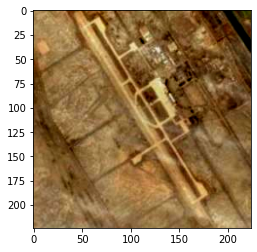

In [37]:
#Permute to put rgb channels as last dimension (tensors have them first)
plt.imshow(tensor_img.permute(1, 2, 0))

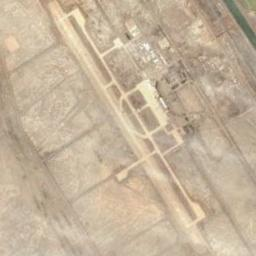

In [38]:
train_ds[0]["image"]

### Train Model

In [40]:
model = AutoModelForImageClassification.from_pretrained(
    model_checkpoint,
    label2id = label2id,
    id2label = id2label,
    ignore_mismatched_sizes = True #fine-tuning an already fine-tuned checkpoint
)
#The ViT from Google was pre-trained on ImageNet-21k and then fine-tuned on ImageNet 2012. As we are
#fine-tuning on another dataset, we must ignore the old output head and replace it with a new,
#randomly-initialised classification head with a custom number of output neurons, specific to RESISC45

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([45, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([45]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [55]:
model_name = model_checkpoint.split("/")[-1]

args = TrainingArguments(
    f"{model_name}-finetuned-resisc45", #folder name
    remove_unused_columns=False, #we need the unused features, in this case 'image' to create 'pixel_values'
    evaluation_strategy = "epoch",
    save_strategy = "epoch",
    learning_rate = 5e-5,
    per_device_train_batch_size = batch_size,
    gradient_accumulation_steps = 4,
    per_device_eval_batch_size = batch_size,
    num_train_epochs = 3,
    warmup_ratio = 0.1,
    logging_steps = 10,
    load_best_model_at_end = True,
    metric_for_best_model = "accuracy",
    push_to_hub = False
)

PyTorch: setting up devices
The default value for the training argument `--report_to` will change in v5 (from all installed integrations to none). In v5, you will need to use `--report_to all` to get the same behavior as now. You should start updating your code and make this info disappear :-).


Function to compute metrics from the predictions. Will just use 'acc' from before, but preprocess by taking argmax of predicted logits.

In [56]:
def compute_acc(eval_pred):
    """Compute accuracy on batch of predictions."""
    preds = np.argmax(eval_pred.predictions, axis=1)
    return acc.compute(predictions=preds, references=eval_pred.label_ids)

collate_fn will be used to batch examples together, where each batch consists of 2 keys: pixel_values and labels.

In [57]:
def collate_fn(examples):
    pixel_values = torch.stack([example["pixel_values"] for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [58]:
trainer = Trainer(
    model,
    args,
    train_dataset = train_ds,
    eval_dataset = val_ds,
    compute_metrics = compute_acc,
    data_collator = collate_fn
)

In [59]:
#GPU
def print_gpu_utilization():
    nvmlInit()
    handle = nvmlDeviceGetHandleByIndex(0)
    info = nvmlDeviceGetMemoryInfo(handle)
    print(f"GPU memory occupied: {info.used//1024**2} MB.")


def print_summary(result):
    print(f"Time: {result.metrics['train_runtime']:.2f}")
    print(f"Samples/second: {result.metrics['train_samples_per_second']:.2f}")
    print_gpu_utilization()

In [64]:
print_gpu_utilization()

GPU memory occupied: 9011 MB.


In [61]:
train_results = trainer.train()

/home/jeevan/myrtle-vision/classification/venv/lib/python3.10/site-packages/transformers/optimization.py:306: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
***** Running training *****
  Num examples = 28350
  Num Epochs = 3
  Instantaneous batch size per device = 32
  Total train batch size (w. parallel, distributed & accumulation) = 128
  Gradient Accumulation steps = 4
  Total optimization steps = 663


Epoch,Training Loss,Validation Loss,Accuracy
0,0.235900,0.248430,0.937143
1,0.104200,0.166132,0.952698
2,0.031400,0.149412,0.955873


***** Running Evaluation *****
  Num examples = 3150
  Batch size = 32
Saving model checkpoint to vit-base-patch16-224-finetuned-resisc45/checkpoint-221
Configuration saved in vit-base-patch16-224-finetuned-resisc45/checkpoint-221/config.json
Model weights saved in vit-base-patch16-224-finetuned-resisc45/checkpoint-221/pytorch_model.bin
***** Running Evaluation *****
  Num examples = 3150
  Batch size = 32
Saving model checkpoint to vit-base-patch16-224-finetuned-resisc45/checkpoint-442
Configuration saved in vit-base-patch16-224-finetuned-resisc45/checkpoint-442/config.json
Model weights saved in vit-base-patch16-224-finetuned-resisc45/checkpoint-442/pytorch_model.bin
***** Running Evaluation *****
  Num examples = 3150
  Batch size = 32
Saving model checkpoint to vit-base-patch16-224-finetuned-resisc45/checkpoint-663
Configuration saved in vit-base-patch16-224-finetuned-resisc45/checkpoint-663/config.json
Model weights saved in vit-base-patch16-224-finetuned-resisc45/checkpoint-663/p

NameError: name 'tainer' is not defined

In [62]:
trainer.save_model()
trainer.log_metrics("train", train_results.metrics)
trainer.save_metrics("train", train_results.metrics)
trainer.save_state()

Saving model checkpoint to vit-base-patch16-224-finetuned-resisc45
Configuration saved in vit-base-patch16-224-finetuned-resisc45/config.json
Model weights saved in vit-base-patch16-224-finetuned-resisc45/pytorch_model.bin


***** train metrics *****
  epoch                    =          3.0
  total_flos               = 6135951154GF
  train_loss               =       0.4742
  train_runtime            =   0:19:55.31
  train_samples_per_second =       71.153
  train_steps_per_second   =        0.555


In [63]:
print_summary(train_results)

Time: 1195.32
Samples/second: 71.15
GPU memory occupied: 9011 MB.
